In [1]:
!pip install catboost lightgbm xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [2]:
# ========================================
# IMPORT MODEL KLASIFIKASI - SKLEARN
# ========================================

# --- Linear Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import PassiveAggressiveClassifier

# --- Naive Bayes ---
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

# --- Support Vector Machine ---
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

# --- Decision Tree ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier

# --- Ensemble ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# --- Neighbors ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid

# --- Discriminant Analysis ---
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- Neural Network ---
from sklearn.neural_network import MLPClassifier

# --- Boosting Lanjutan ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Save model
import pickle

# ============================================================
# IMPORT LENGKAP - PREPROCESSING, SPLITTING, TUNING, METRIK
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')


## Business Understanding

### Background Context
Sebuah perusahaan **penerbit kartu kredit** ingin mengetahui nasabah mana yang berpotensi **gagal bayar (default)** pada bulan berikutnya, berdasarkan riwayat limit kredit, status pembayaran, dan tagihan 6 bulan terakhir.

### Problem Statement
Perusahaan belum memiliki cara sistematis untuk mengidentifikasi nasabah yang berisiko gagal membayar tagihan kartu kredit bulan depan, sehingga proses mitigasi risiko (penagihan dini, penyesuaian limit, dsb) tidak bisa dilakukan secara proaktif.

### Goal
Membangun model *machine learning* yang mampu memprediksi apakah seorang nasabah akan **default (gagal bayar)** pada bulan berikutnya (`default.payment.next.month` = 1) atau tidak (0).

### Stakeholder
Head of Credit Risk Division

### Analytical Approach
Klasifikasi biner (*binary classification*) menggunakan *machine learning*, dievaluasi terutama dengan **F1-score** dan **ROC-AUC** karena target bersifat *imbalanced* (~22% default).

### Deskripsi Kolom (Data Dictionary)
| Kolom | Keterangan |
|---|---|
| ID | ID unik nasabah |
| LIMIT_BAL | Limit kredit (NT dollar) |
| SEX | 1 = pria, 2 = wanita |
| EDUCATION | 1=graduate school, 2=university, 3=high school, 4=others |
| MARRIAGE | 1=menikah, 2=lajang, 3=lainnya |
| AGE | Usia |
| PAY_0, PAY_2..PAY_6 | Status pembayaran bulan-bulan sebelumnya (-1=lunas tepat waktu, 1-9=terlambat n bulan) |
| BILL_AMT1..6 | Jumlah tagihan tiap bulan |
| PAY_AMT1..6 | Jumlah yang dibayarkan tiap bulan |
| default.payment.next.month | Target: 1 = default, 0 = tidak default |


In [29]:
df = pd.read_csv('/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
df.shape

## Data Cleaning
Menangani data duplikat, outlier, dan data yang tidak relevan.

In [15]:
# Cek duplikat
print("Jumlah baris duplikat:", df.duplicated().sum())

# Kolom ID tidak relevan untuk pemodelan (hanya identifier), akan dibuang nanti dari fitur
print("Jumlah nilai unik ID:", df['ID'].nunique(), "dari", len(df), "baris")

Jumlah baris duplikat: 0
Jumlah nilai unik ID: 30000 dari 30000 baris


In [31]:
# Cek missing value
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [32]:
# Cek kategori tidak wajar pada EDUCATION dan MARRIAGE (menurut dokumentasi UCI seharusnya EDUCATION 1-4, MARRIAGE 1-3)
print(df['EDUCATION'].value_counts())
print()
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [19]:
# Rapikan kategori EDUCATION: 0, 5, 6 dianggap "others" -> gabung ke kategori 4
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Rapikan kategori MARRIAGE: 0 dianggap "others" -> gabung ke kategori 3
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print(df['EDUCATION'].value_counts())
print()
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)
Menganalisis hubungan fitur dengan target secara visual.

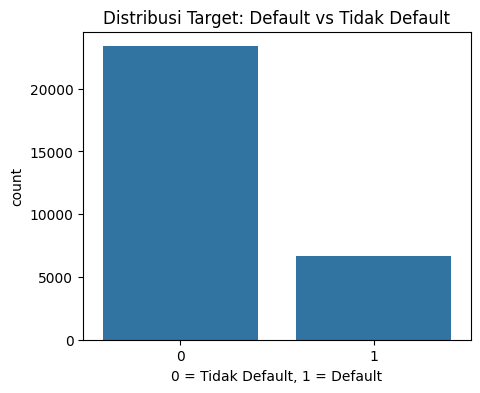

,proportion
default.payment.next.month,
0,0.7788
1,0.2212


In [20]:
# Distribusi target (cek imbalance)
plt.figure(figsize=(5,4))
sns.countplot(x='default.payment.next.month', data=df)
plt.title('Distribusi Target: Default vs Tidak Default')
plt.xlabel('0 = Tidak Default, 1 = Default')
plt.show()

df['default.payment.next.month'].value_counts(normalize=True)

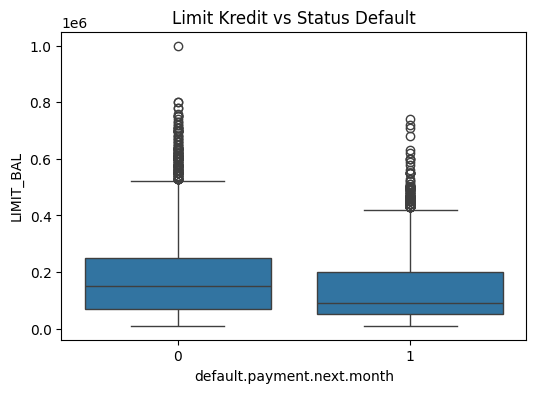

In [21]:
# Distribusi LIMIT_BAL terhadap target
plt.figure(figsize=(6,4))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title('Limit Kredit vs Status Default')
plt.show()

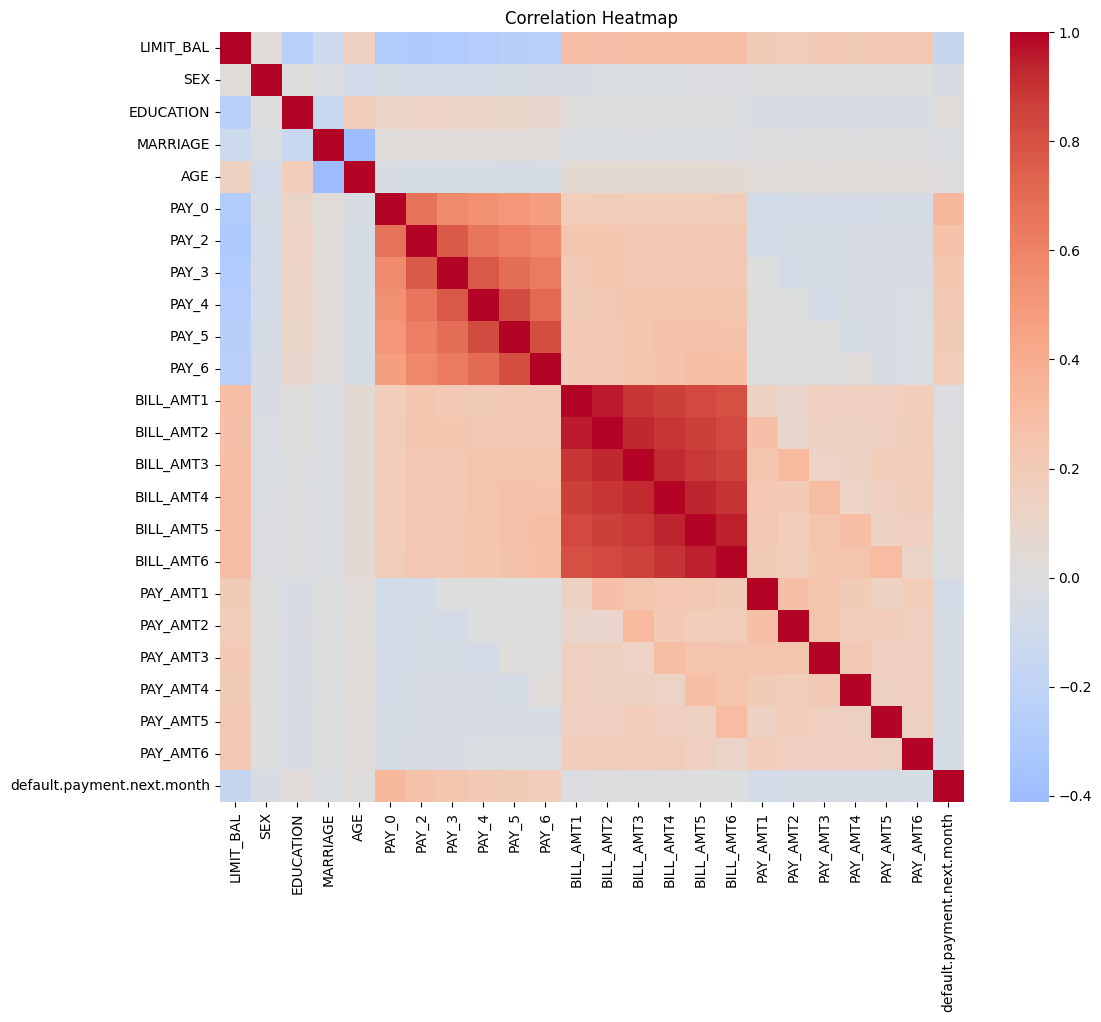

In [22]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=['ID']).corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

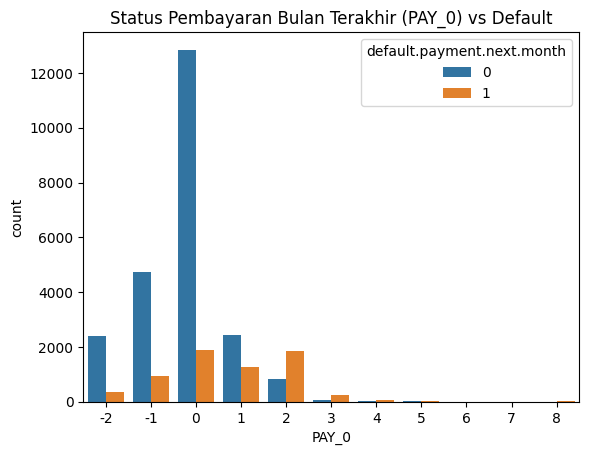

In [33]:
# Rata-rata status pembayaran (PAY_0) terhadap target
sns.countplot(x='PAY_0', hue='default.payment.next.month', data=df)
plt.title('Status Pembayaran Bulan Terakhir (PAY_0) vs Default')
plt.show()

## Define Feature & Label

In [23]:
# Feature: semua kolom kecuali ID (identifier) dan target
feature_cols = [c for c in df.columns if c not in ['ID', 'default.payment.next.month']]

X = df[feature_cols]
y = df['default.payment.next.month']

print("Jumlah fitur:", len(feature_cols))
X.head()

Jumlah fitur: 23


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,2,2,2,26,-1,2,0,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,2,2,2,34,0,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,2,2,1,37,0,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0


## Split Data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=10
)

# train -> untuk melatih model, test -> untuk evaluasi model
print(X_train.shape, X_test.shape)

(24000, 23) (6000, 23)


## Preprocessor Pipeline
Seluruh fitur pada dataset ini bersifat **numerik** (termasuk SEX, EDUCATION, MARRIAGE, dan PAY_x yang berupa kode angka), sehingga preprocessing difokuskan pada imputasi & scaling numerik. Tidak ada kolom bertipe teks/kategorikal string di dataset ini.

In [25]:
numeric_features = feature_cols  # semua fitur numerik

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

## Modeling

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SGD Classifier": SGDClassifier(loss='log_loss'),
    "Ridge Classifier": RidgeClassifier(),
    "Passive Aggressive": PassiveAggressiveClassifier(),
    "Gaussian NB": GaussianNB(),
    "Bernoulli NB": BernoulliNB(),
    "Linear SVC": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Extra Tree (single)": ExtraTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Nearest Centroid": NearestCentroid(),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP Neural Network": MLPClassifier(max_iter=500),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0)
}
# Catatan: SVC dan NuSVC sengaja tidak dimasukkan karena dataset besar (30rb baris)
# akan membuat training sangat lambat (kompleksitas O(n^2) - O(n^3)).

def benchmark_models(X_train, X_test, y_train, y_test):
    results = []
    print("Mulai proses benchmarking. Proses ini mungkin memakan waktu...\n")
    for model_name, model in models.items():
        try:
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier', model)
            ])
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
                y_scores = pipeline.predict_proba(X_test)[:, 1]
            elif hasattr(pipeline.named_steps['classifier'], "decision_function"):
                y_scores = pipeline.decision_function(X_test)
            else:
                y_scores = None

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc_auc = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

            results.append({'Model': model_name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc_auc})
            print(f"\u2705 Selesai: {model_name}")
        except Exception as e:
            print(f"\u274c Gagal: {model_name} (Alasan: {str(e).split('.')[0]})")
            results.append({'Model': model_name, 'Accuracy': np.nan, 'F1-Score': np.nan, 'ROC-AUC': np.nan})

    results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
    return results_df

hasil = benchmark_models(X_train, X_test, y_train, y_test)
hasil

Mulai proses benchmarking. Proses ini mungkin memakan waktu...

✅ Selesai: Logistic Regression
✅ Selesai: SGD Classifier
✅ Selesai: Ridge Classifier
✅ Selesai: Passive Aggressive
✅ Selesai: Gaussian NB
✅ Selesai: Bernoulli NB
✅ Selesai: Linear SVC
✅ Selesai: Decision Tree
✅ Selesai: Extra Tree (single)
✅ Selesai: Random Forest
✅ Selesai: Gradient Boosting
✅ Selesai: AdaBoost
✅ Selesai: Bagging
✅ Selesai: Extra Trees
✅ Selesai: Hist Gradient Boosting
✅ Selesai: K-Nearest Neighbors
✅ Selesai: Nearest Centroid
✅ Selesai: LDA
✅ Selesai: MLP Neural Network
✅ Selesai: XGBoost
✅ Selesai: LightGBM
✅ Selesai: CatBoost


,Model,Accuracy,F1-Score,ROC-AUC
0,Gradient Boosting,0.817500,0.472797,0.785213
1,Hist Gradient Boosting,0.819333,0.478345,0.782697
2,LightGBM,0.820833,0.486874,0.779987
3,CatBoost,0.818000,0.482464,0.778425
4,AdaBoost,0.818333,0.450605,0.769957
5,Random Forest,0.814167,0.473808,0.764282
6,XGBoost,0.810667,0.465160,0.761001
7,MLP Neural Network,0.810500,0.464437,0.758165
8,Extra Trees,0.810167,0.468998,0.755693
9,Gaussian NB,0.745833,0.511375,0.732208


## Hyperparameter Tuning
Tuning dilakukan pada beberapa model kandidat terbaik dari hasil benchmarking di atas.

In [27]:
tuning_configs = [
    {
        'name': 'CatBoost',
        'model': CatBoostClassifier(verbose=0),
        'params': {
            'model__iterations': [100, 200],
            'model__depth': [4, 6]
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMClassifier(verbose=-1),
        'params': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1]
        }
    },
    {
        'name': 'Hist Gradient Boosting',
        'model': HistGradientBoostingClassifier(),
        'params': {
            'model__max_iter': [100, 200],
            'model__learning_rate': [0.05, 0.1]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(eval_metric='logloss'),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5]
        }
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__n_estimators': [50, 100],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        }
    }
]

def tune_top_models(X_train, y_train):
    best_models = {}
    tuning_results = []
    print("Mulai Hyperparameter Tuning (Mode: Cepat/Tidak Greedy)...\n")

    for config in tuning_configs:
        model_name = config['name']
        model = config['model']
        params = config['params']

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        grid_search = GridSearchCV(
            pipeline,
            param_grid=params,
            cv=3,
            scoring='f1',
            n_jobs=-1
        )

        print(f"\U0001f504 Tuning {model_name}...")
        grid_search.fit(X_train, y_train)

        best_models[model_name] = grid_search.best_estimator_
        tuning_results.append({
            'Model': model_name,
            'Best F1 (CV)': grid_search.best_score_,
            'Best Parameters': grid_search.best_params_
        })

        print(f"\u2705 Selesai {model_name} | Best F1: {grid_search.best_score_:.4f}")
        print(f"   Parameter: {grid_search.best_params_}\n")

    return best_models, pd.DataFrame(tuning_results).sort_values(by='Best F1 (CV)', ascending=False)

model_terbaik_dict, tabel_hasil_tuning = tune_top_models(X_train, y_train)
tabel_hasil_tuning

Mulai Hyperparameter Tuning (Mode: Cepat/Tidak Greedy)...

🔄 Tuning CatBoost...
✅ Selesai CatBoost | Best F1: 0.4763
   Parameter: {'model__depth': 6, 'model__iterations': 200}

🔄 Tuning LightGBM...
✅ Selesai LightGBM | Best F1: 0.4747
   Parameter: {'model__learning_rate': 0.1, 'model__n_estimators': 100}

🔄 Tuning Hist Gradient Boosting...
✅ Selesai Hist Gradient Boosting | Best F1: 0.4771
   Parameter: {'model__learning_rate': 0.1, 'model__max_iter': 100}

🔄 Tuning XGBoost...
✅ Selesai XGBoost | Best F1: 0.4763
   Parameter: {'model__max_depth': 3, 'model__n_estimators': 100}

🔄 Tuning Random Forest...
✅ Selesai Random Forest | Best F1: 0.4740
   Parameter: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}



,Model,Best F1 (CV),Best Parameters
2,Hist Gradient Boosting,0.477143,"{'model__learning_rate': 0.1, 'model__max_iter..."
3,XGBoost,0.476322,"{'model__max_depth': 3, 'model__n_estimators':..."
0,CatBoost,0.476286,"{'model__depth': 6, 'model__iterations': 200}"
1,LightGBM,0.474733,"{'model__learning_rate': 0.1, 'model__n_estima..."
4,Random Forest,0.473997,"{'model__max_depth': 20, 'model__min_samples_s..."


## Evaluasi Model Terbaik pada Data Test

In [28]:
nama_model_terbaik = tabel_hasil_tuning.iloc[0]['Model']
best_pipeline = model_terbaik_dict[nama_model_terbaik]

y_pred_test = best_pipeline.predict(X_test)
if hasattr(best_pipeline.named_steps['model'], 'predict_proba'):
    y_scores_test = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_scores_test = best_pipeline.decision_function(X_test)

print(f"Model terbaik: {nama_model_terbaik}\n")
print(classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_scores_test))

Model terbaik: Hist Gradient Boosting

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7846693740484506


In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Default','Default'],
            yticklabels=['Tidak Default','Default'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - {nama_model_terbaik}')
plt.show()

## Simpan Model Final
Model final di-*fit ulang* pada seluruh data (`X`, `y`) sebelum disimpan, supaya memanfaatkan seluruh data yang tersedia untuk versi produksi.

In [35]:
best_model = model_terbaik_dict[nama_model_terbaik]
best_model.fit(X, y)

with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f"\u2705 Model berhasil disimpan ke file: best_model.pkl")

# Cara load model kembali:
# with open('best_model.pkl', 'rb') as file:
#     loaded_model = pickle.load(file)
# loaded_model.predict(X_data_baru)

✅ Model berhasil disimpan ke file: best_model.pkl


## Limitasi Model
Model hanya valid diterapkan pada data baru yang berada dalam rentang nilai fitur berikut (di luar rentang ini, prediksi model kurang bisa diandalkan / *extrapolation*).

In [34]:
X.describe().T[['min','max']]

,min,max
LIMIT_BAL,10000.0,1000000.0
SEX,1.0,2.0
EDUCATION,1.0,4.0
MARRIAGE,1.0,3.0
AGE,21.0,79.0
PAY_0,-2.0,8.0
PAY_2,-2.0,8.0
PAY_3,-2.0,8.0
PAY_4,-2.0,8.0
PAY_5,-2.0,8.0


**Catatan limitasi tambahan:**
- Dataset bersifat *imbalanced* (~22% kelas default), sehingga model cenderung lebih baik memprediksi kelas mayoritas (tidak default); perlu dipantau *recall* pada kelas default.
- Model dilatih pada data historis nasabah Taiwan (dataset UCI), sehingga generalisasi ke populasi/negara lain perlu divalidasi ulang.
- Fitur PAY_0..PAY_6, BILL_AMT, PAY_AMT bersifat *time-dependent* (snapshot 6 bulan); performa bisa menurun jika pola perilaku pembayaran nasabah berubah signifikan dari waktu ke waktu (*data drift*).
